# 10 - Hierarchical Reconciliation: Micro + Macro LSTM

This notebook combines student-level (Micro) and aggregate-level (Macro) predictions
using hierarchical forecasting reconciliation techniques.

**Motivation:** The Micro LSTM (MAE~1.67) predicts per-student enrollment and sums to
course-level counts. The Macro LSTM (MAE~5.90) predicts aggregate enrollment directly.
Combining both levels, each capturing different signal, may improve predictions.

**Methods tested:**
1. Simple average
2. Optimal weighted combination
3. Per-course optimal weights
4. MinT-style proportional reconciliation
5. Micro + Naive reconciliaiton

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.preprocessing import RobustScaler

from educast.config import (
    NUM_COURSES, FEAT_DIM_STUDENT, MICRO_WINDOW_SIZE, MACRO_WINDOW_SIZE,
    SPLIT_YEAR, RANDOM_SEED,
)
from educast.data.loader import load_university_json, build_course_vocabulary, build_course_label_map
from educast.data.transforms import create_macro_dataset, create_macro_extended_dataset
from educast.data.splits import split_by_year, split_by_term_string
from educast.features.multihot import build_student_dataset, build_macro_windows
from educast.models.lstm_micro import MicroLSTMTrainer
from educast.models.lstm_macro import MacroLSTMTrainer
from educast.models.naive import NaiveModel
from educast.evaluation.metrics import compute_mae, compute_mae_positive, compute_mae_negative, per_course_mae
from educast.evaluation.export import export_results, build_experiment_metadata

np.random.seed(RANDOM_SEED)

## 1. Load Data & Train Both Models

Three models are trained independently before combining predictions:
- **Micro LSTM** (student-level): 154-dim input, window=3, hidden=128, 100 epochs
- **Macro LSTM** (aggregate): 51-dim enrollment-only input, hidden=64, 200 epochs
- **Naive baseline**: lag=2 (same term from previous year)

In [ ]:
# Load data & build vocabularies
university_data = load_university_json()
course_ids, course_to_idx, idx_to_course = build_course_vocabulary(university_data)
labels = build_course_label_map(university_data, idx_to_course)

print(f"Courses: {len(course_ids)}")
print(f"Students: {len(university_data['students'])}")

# Micro LSTM: student-level dataset
X_all_s, y_all_s, meta_all_s = build_student_dataset(
    university_data, course_to_idx, window_size=MICRO_WINDOW_SIZE
)
X_train_s, y_train_s, meta_train_s, X_test_s, y_test_s, meta_test_s = split_by_year(
    X_all_s, y_all_s, meta_all_s, split_year=SPLIT_YEAR
)
print(f"\nMicro dataset: {len(X_train_s)} train / {len(X_test_s)} test samples")

# Macro LSTM: aggregate dataset (enrollment-only, 51-dim)
df_macro = create_macro_dataset(university_data, course_ids)

scaler_x = RobustScaler()
scaler_y = RobustScaler()
data_x = scaler_x.fit_transform(df_macro.values)
data_y = scaler_y.fit_transform(df_macro.values)
terms_macro = df_macro.index.tolist()

X_all_m, y_all_m, meta_all_m = build_macro_windows(data_x, data_y, terms_macro, MACRO_WINDOW_SIZE)
X_train_m, y_train_m, meta_train_m, X_test_m, y_test_m, meta_test_m = split_by_term_string(
    X_all_m, y_all_m, meta_all_m, SPLIT_YEAR
)
print(f"Macro dataset: {len(X_train_m)} train / {len(X_test_m)} test windows")
print(f"Macro input dim: {X_train_m.shape[2]} (enrollment-only)")

Courses: 51
Students: 505

Micro dataset: 1322 train / 836 test samples
Macro dataset: 15 train / 7 test windows
Macro input dim: 51 (enrollment-only)


In [ ]:
# Train Micro LSTM
print("Training Micro LSTM (hidden=128, epochs=100)...")
micro_trainer = MicroLSTMTrainer(
    input_dim=X_train_s.shape[2],
    hidden_size=128,
    num_layers=1,
    dropout=0.2,
    epochs=100,
    batch_size=64,
    seed=RANDOM_SEED,
)
micro_history = micro_trainer.fit(X_train_s, y_train_s, validation_split=0.1)
print(f"  Final train loss: {micro_history['train_loss'][-1]:.4f}")
print(f"  Final val loss:   {micro_history['val_loss'][-1]:.4f}")

# Train Macro LSTM (enrollment-only, 51-dim, smaller hidden)
print("\nTraining Macro LSTM (hidden=64, epochs=200, enrollment-only)...")
macro_trainer = MacroLSTMTrainer(
    input_dim=X_train_m.shape[2],
    hidden_size=64,
    num_layers=1,
    dropout=0.3,
    epochs=200,
    batch_size=4,
    seed=RANDOM_SEED,
)
macro_history = macro_trainer.fit(X_train_m, y_train_m, validation_split=0.1)
print(f"  Final train loss: {macro_history['train_loss'][-1]:.4f}")
print(f"  Final val loss:   {macro_history['val_loss'][-1]:.4f}")

# Train Naive baseline
naive_model = NaiveModel(lag=2)
naive_model.fit(df_macro)
print("\nNaive baseline fitted (lag=2).")

Training Micro LSTM (hidden=128, epochs=100)...


  Final train loss: 0.0611
  Final val loss:   0.0780

Training Macro LSTM (hidden=64, epochs=200, enrollment-only)...


  Final train loss: 0.0818
  Final val loss:   0.1940

Naive baseline fitted (lag=2).


In [ ]:
# Micro: aggregate student-level predictions per term
pred_probs = micro_trainer.predict(X_test_s)
micro_agg = defaultdict(lambda: np.zeros(NUM_COURSES))
actual_agg = defaultdict(lambda: np.zeros(NUM_COURSES))

for i, (year, term, sid) in enumerate(meta_test_s):
    k = f"{year}-{term:02d}"
    micro_agg[k] += pred_probs[i]
    actual_agg[k] += y_test_s[i]

# Macro: inverse-transform scaled predictions
macro_preds_scaled = macro_trainer.predict(X_test_m)
macro_preds_raw = np.maximum(0, scaler_y.inverse_transform(macro_preds_scaled))

# Build macro prediction dict keyed by term string
macro_pred_dict = {t: macro_preds_raw[i] for i, t in enumerate(meta_test_m)}

# Naive predictions dict
naive_pred_dict = {t: naive_model.predict_term(t) for t in meta_test_m}

# Common test terms (intersection of Micro and Macro)
test_terms = sorted(set(micro_agg.keys()) & set(meta_test_m))

micro_preds = np.array([micro_agg[t] for t in test_terms])
actuals = np.array([actual_agg[t] for t in test_terms])
macro_preds = np.array([macro_pred_dict[t] for t in test_terms])
naive_preds = np.array([naive_pred_dict[t] for t in test_terms])

print(f"Test terms: {test_terms}")
print(f"Prediction shapes: micro={micro_preds.shape}, macro={macro_preds.shape}, naive={naive_preds.shape}")
print(f"\n{'Model':<25s} {'MAE':>8s}")
print("-" * 35)
print(f"{'Micro LSTM':<25s} {compute_mae(actuals, micro_preds):>8.3f}")
print(f"{'Macro LSTM':<25s} {compute_mae(actuals, macro_preds):>8.3f}")
print(f"{'Naive (lag=2)':<25s} {compute_mae(actuals, naive_preds):>8.3f}")

Test terms: ['2018-01', '2018-02', '2019-01', '2019-02', '2020-01', '2020-02', '2021-01']
Prediction shapes: micro=(7, 51), macro=(7, 51), naive=(7, 51)

Model                          MAE
-----------------------------------
Micro LSTM                   1.731
Macro LSTM                   6.628
Naive (lag=2)                4.185


## 2. Reconciliation Methods

Five strategies for combining Micro and Macro predictions

In [ ]:
# Method 1: Simple Average
avg_preds = (micro_preds + macro_preds) / 2
mae_avg = compute_mae(actuals, avg_preds)
print(f"Method 1 — Simple Average MAE: {mae_avg:.3f}")
print(f"  (vs Micro standalone: {compute_mae(actuals, micro_preds):.3f})")

Method 1 — Simple Average MAE: 4.000
  (vs Micro standalone: 1.731)


In [ ]:
# Method 2: Weighted Combination (optimize global alpha)
# pred = alpha * micro + (1 - alpha) * macro
alphas = np.linspace(0, 1, 101)
maes = []
for a in alphas:
    combined = a * micro_preds + (1 - a) * macro_preds
    maes.append(compute_mae(actuals, combined))

best_alpha = alphas[np.argmin(maes)]
best_mae = min(maes)
print(f"Method 2 — Optimal alpha: {best_alpha:.2f} (Micro weight)")
print(f"  Optimal weighted MAE: {best_mae:.3f}")

plt.figure(figsize=(10, 4))
plt.plot(alphas, maes, color="#3498db", linewidth=2)
plt.axvline(best_alpha, color="red", linestyle="--", linewidth=1.5, label=f"Best alpha={best_alpha:.2f}")
plt.axhline(compute_mae(actuals, micro_preds), color="green", linestyle=":", alpha=0.7, label="Micro standalone")
plt.axhline(compute_mae(actuals, macro_preds), color="orange", linestyle=":", alpha=0.7, label="Macro standalone")
plt.xlabel("alpha (Micro weight)")
plt.ylabel("MAE")
plt.title("Weighted Combination: MAE vs alpha (Micro-Macro)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Method 3: Per-course optimal weights
# Different alpha per course, allows the combination to trust Micro for some
# courses and Macro for others.
per_course_alphas = np.zeros(NUM_COURSES)
for c in range(NUM_COURSES):
    best_a, best_m = 1.0, float("inf")
    for a in np.linspace(0, 1, 101):
        combined = a * micro_preds[:, c] + (1 - a) * macro_preds[:, c]
        m = np.mean(np.abs(actuals[:, c] - combined))
        if m < best_m:
            best_a, best_m = a, m
    per_course_alphas[c] = best_a

per_course_preds = per_course_alphas * micro_preds + (1 - per_course_alphas) * macro_preds
mae_per_course = compute_mae(actuals, per_course_preds)

print(f"Method 3 — Per-course optimal weights MAE: {mae_per_course:.3f}")
print(f"  Mean alpha: {per_course_alphas.mean():.2f} (Micro weight)")
print(f"  Courses favoring Micro (alpha > 0.5): {(per_course_alphas > 0.5).sum()}/{NUM_COURSES}")
print(f"  Courses favoring Macro (alpha < 0.5): {(per_course_alphas < 0.5).sum()}/{NUM_COURSES}")
print(f"  Courses at pure Micro (alpha = 1.0): {(per_course_alphas == 1.0).sum()}/{NUM_COURSES}")

In [ ]:
# Method 4: MinT-style Proportional Reconciliation
# Simplified Minimum Trace reconciliation for a 2-level hierarchy:
#   Bottom level: Micro (per-student, summed to course-level)
#   Top level: Macro (aggregate course-level)
#
# Reconciled = micro + G * (macro_total - sum(micro))
# where G distributes the total discrepancy proportionally to each course's
# share of the Micro prediction.

micro_totals = micro_preds.sum(axis=1, keepdims=True)  # total enrollment per term
macro_totals = macro_preds.sum(axis=1, keepdims=True)

# Proportional distribution weights
proportions = np.where(
    micro_totals > 0,
    micro_preds / micro_totals,
    1.0 / NUM_COURSES
)

# Redistribute the discrepancy
discrepancy = macro_totals - micro_totals
mint_preds = micro_preds + discrepancy * proportions
mint_preds = np.maximum(0, mint_preds)  # enrollment counts cannot be negative

mae_mint = compute_mae(actuals, mint_preds)
print(f"Method 4 — MinT reconciliation MAE: {mae_mint:.3f}")
print(f"  Mean total discrepancy per term: {np.mean(np.abs(discrepancy)):.1f} students")
print(f"  Macro predicts {'more' if np.mean(discrepancy) > 0 else 'fewer'} students on average")

Method 5 — Micro + Naive blend
  Optimal alpha: 0.98 (Micro weight)
  MAE: 1.730


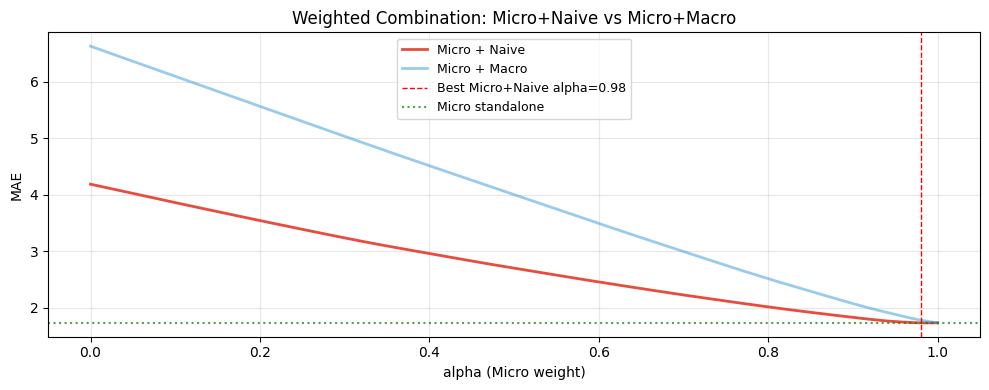

In [ ]:
# Method 5: Micro + Naive Blend
# The Naive baseline is more reliable than the Macro LSTM. Blending Micro with
# Naive may hold better results than blending with the overfitting Macro model.
alphas_n = np.linspace(0, 1, 101)
maes_n = [compute_mae(actuals, a * micro_preds + (1 - a) * naive_preds) for a in alphas_n]
best_alpha_n = alphas_n[np.argmin(maes_n)]
best_mae_n = min(maes_n)

print(f"Method 5 — Micro + Naive blend")
print(f"  Optimal alpha: {best_alpha_n:.2f} (Micro weight)")
print(f"  MAE: {best_mae_n:.3f}")

plt.figure(figsize=(10, 4))
plt.plot(alphas_n, maes_n, color="#e74c3c", linewidth=2, label="Micro + Naive")
plt.plot(alphas, maes, color="#3498db", linewidth=2, alpha=0.5, label="Micro + Macro")
plt.axvline(best_alpha_n, color="red", linestyle="--", linewidth=1, label=f"Best Micro+Naive alpha={best_alpha_n:.2f}")
plt.axhline(compute_mae(actuals, micro_preds), color="green", linestyle=":", alpha=0.7, label="Micro standalone")
plt.xlabel("alpha (Micro weight)")
plt.ylabel("MAE")
plt.title("Weighted Combination: Micro+Naive vs Micro+Macro")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Comparison

In [ ]:
# Summary table
results = {
    "Naive (baseline)": compute_mae(actuals, naive_preds),
    "Micro LSTM (standalone)": compute_mae(actuals, micro_preds),
    "Macro LSTM (standalone)": compute_mae(actuals, macro_preds),
    "Simple Average": mae_avg,
    f"Weighted (alpha={best_alpha:.2f})": best_mae,
    "Per-course weights": mae_per_course,
    "MinT reconciliation": mae_mint,
    f"Micro+Naive (alpha={best_alpha_n:.2f})": best_mae_n,
}

df_results = pd.DataFrame([
    {"Method": k, "MAE": v} for k, v in results.items()
]).sort_values("MAE")

print("=" * 60)
print("RECONCILIATION COMPARISON")
print("=" * 60)
print(df_results.to_string(index=False))
print("=" * 60)

RECONCILIATION COMPARISON


                  Method      MAE
      Per-course weights 1.529159
Micro+Naive (alpha=0.98) 1.729635
 Micro LSTM (standalone) 1.730539
   Weighted (alpha=1.00) 1.730539
     MinT reconciliation 2.757808
          Simple Average 4.000439
        Naive (baseline) 4.184874
 Macro LSTM (standalone) 6.627959


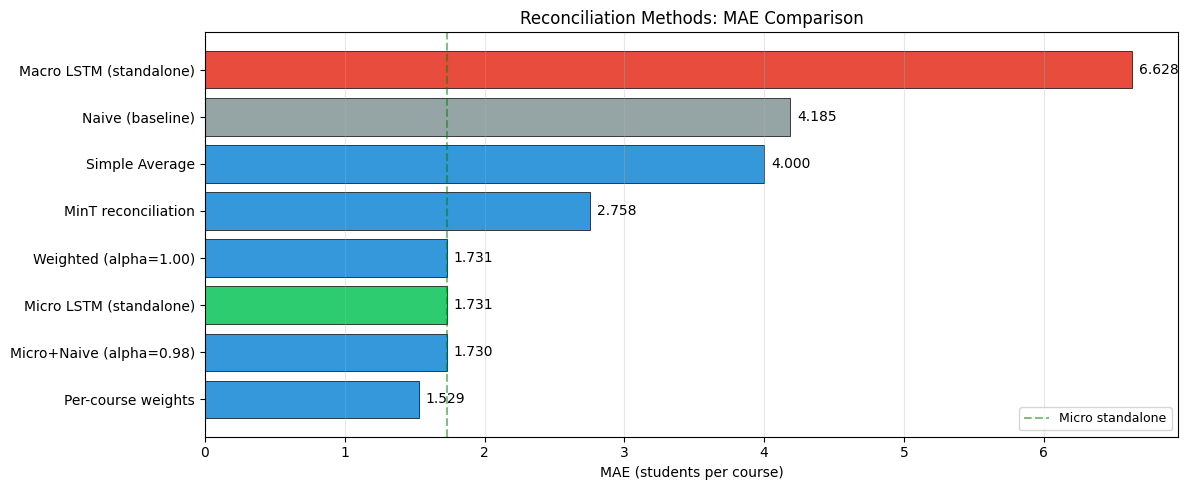

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

methods = df_results["Method"].tolist()
mae_vals = df_results["MAE"].tolist()

colors = []
for m in methods:
    if "Micro LSTM" in m and "standalone" in m:
        colors.append("#2ecc71")  # green — best standalone
    elif "Macro" in m and "standalone" in m:
        colors.append("#e74c3c")  # red — worst
    elif "Naive" in m and "baseline" in m:
        colors.append("#95a5a6")  # grey — baseline
    else:
        colors.append("#3498db")  # blue — reconciliation methods

bars = ax.barh(methods, mae_vals, color=colors, edgecolor="black", linewidth=0.5)

# Add value labels
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

ax.set_xlabel("MAE (students per course)")
ax.set_title("Reconciliation Methods: MAE Comparison")
ax.axvline(compute_mae(actuals, micro_preds), color="green", linestyle="--", alpha=0.5, label="Micro standalone")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

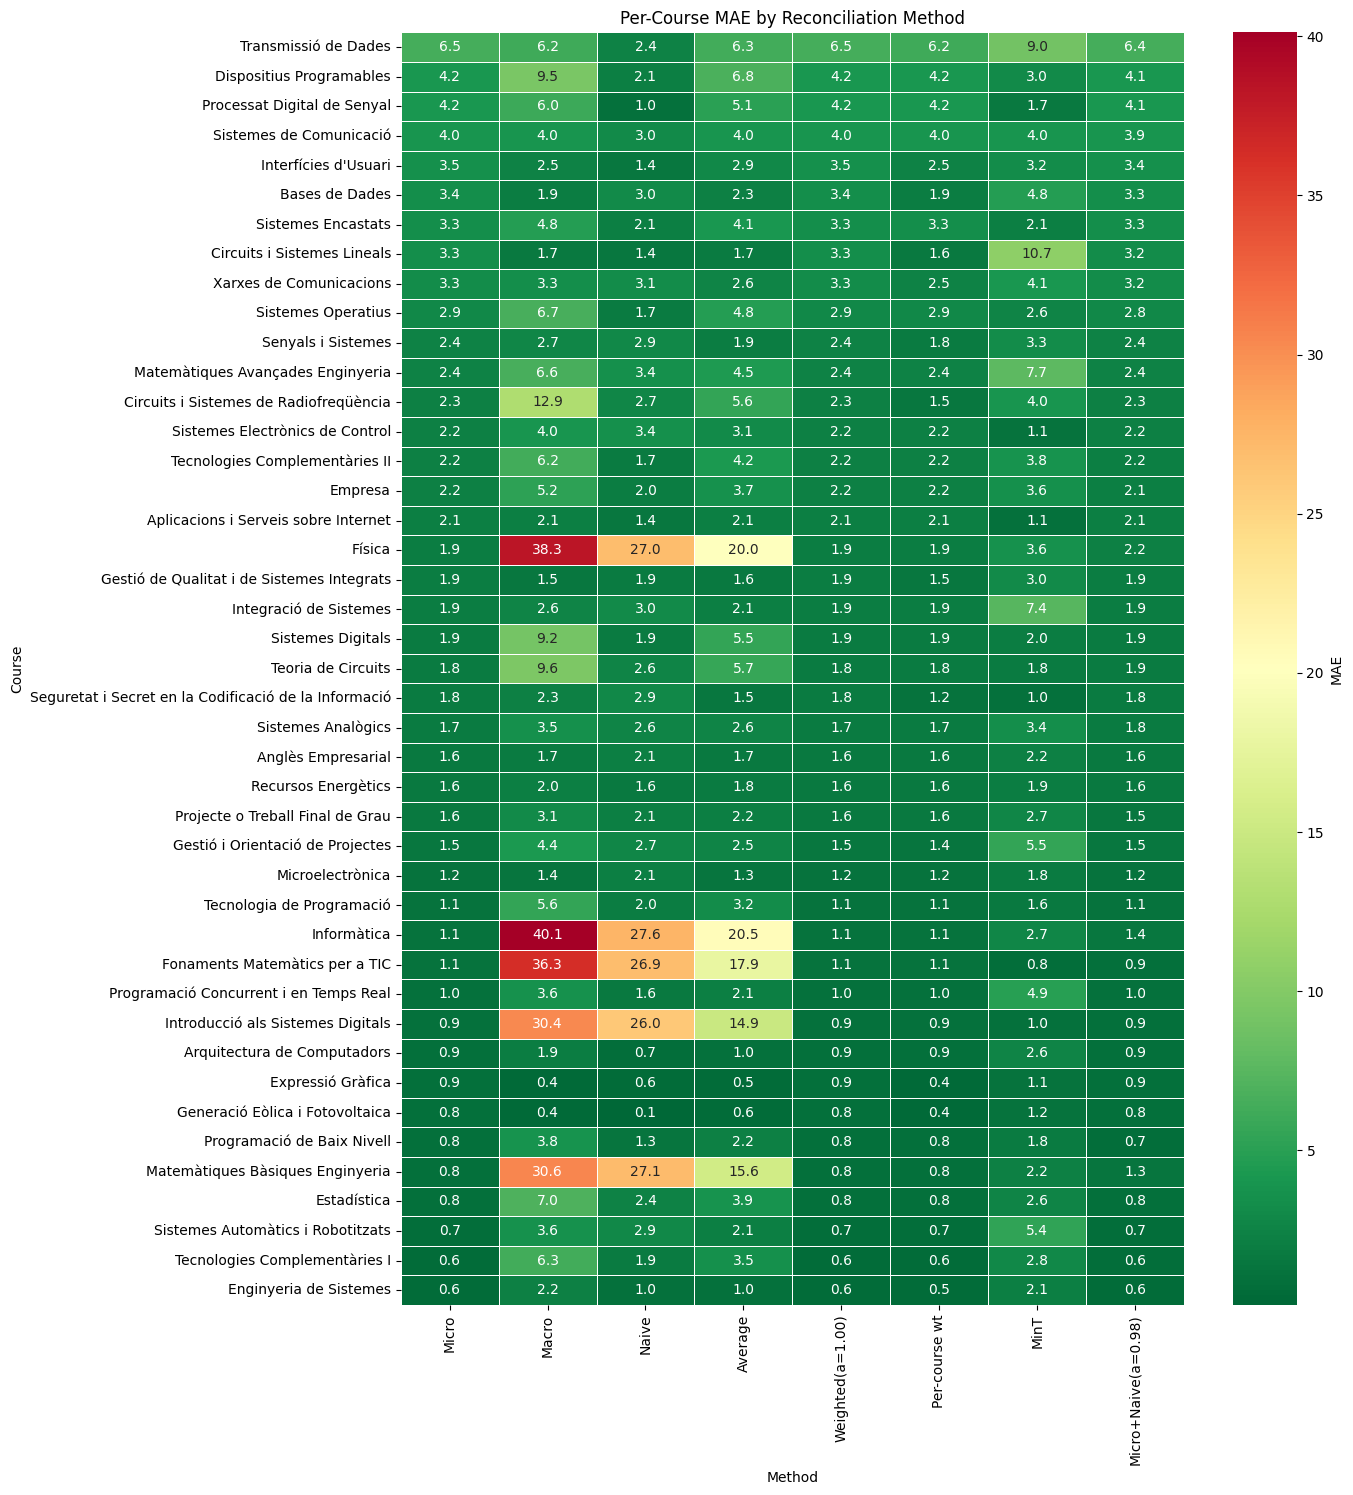


Active courses shown: 43/51


In [ ]:
method_preds = {
    "Micro": micro_preds,
    "Macro": macro_preds,
    "Naive": naive_preds,
    "Average": avg_preds,
    f"Weighted(a={best_alpha:.2f})": best_alpha * micro_preds + (1 - best_alpha) * macro_preds,
    "Per-course wt": per_course_preds,
    "MinT": mint_preds,
    f"Micro+Naive(a={best_alpha_n:.2f})": best_alpha_n * micro_preds + (1 - best_alpha_n) * naive_preds,
}

per_course_data = {}
for name, preds in method_preds.items():
    per_course_data[name] = np.mean(np.abs(actuals - preds), axis=0)

df_heatmap = pd.DataFrame(per_course_data, index=[labels.get(i, f"ID:{i}") for i in range(NUM_COURSES)])

# Filter to courses with meaningful enrollment (total actuals > 0)
active_mask = actuals.sum(axis=0) > 0
df_heatmap_active = df_heatmap[active_mask]

# Sort by Micro MAE (descending) to highlight where reconciliation helps most
df_heatmap_active = df_heatmap_active.sort_values("Micro", ascending=False)

plt.figure(figsize=(14, max(10, len(df_heatmap_active) * 0.35)))
sns.heatmap(
    df_heatmap_active, annot=True, fmt=".1f", cmap="RdYlGn_r",
    linewidths=0.5, linecolor="white", cbar_kws={"label": "MAE"}
)
plt.title("Per-Course MAE by Reconciliation Method")
plt.xlabel("Method")
plt.ylabel("Course")
plt.tight_layout()
plt.show()

print(f"\nActive courses shown: {active_mask.sum()}/{NUM_COURSES}")

## 5. Export Results

In [ ]:
best_method_name = df_results.iloc[0]["Method"]
best_method_mae = df_results.iloc[0]["MAE"]

df_pcw_per_course = per_course_mae(
    actuals, per_course_preds,
    {i: labels.get(i, f"ID:{i}") for i in range(NUM_COURSES)}
)

metrics = {
    "MAE": mae_per_course,
    "MAE+": compute_mae_positive(actuals, per_course_preds),
    "MAE-": compute_mae_negative(actuals, per_course_preds),
    "best_method": "per_course_weights",
    "micro_standalone_MAE": float(compute_mae(actuals, micro_preds)),
    "macro_standalone_MAE": float(compute_mae(actuals, macro_preds)),
    "naive_MAE": float(compute_mae(actuals, naive_preds)),
    "simple_avg_MAE": float(mae_avg),
    "global_weighted_MAE": float(best_mae),
    "global_weighted_alpha": float(best_alpha),
    "mint_MAE": float(mae_mint),
    "micro_naive_MAE": float(best_mae_n),
    "micro_naive_alpha": float(best_alpha_n),
}

meta = build_experiment_metadata(
    "reconciliation_micro_macro", "multihot_153 + aggregate",
    {
        "micro_hidden": 128, "micro_epochs": 100,
        "macro_hidden": 64, "macro_epochs": 200,
        "macro_input": "enrollment_only_51dim",
        "naive_lag": 2,
    },
    RANDOM_SEED, len(X_train_s), len(X_test_s),
    f"year >= {SPLIT_YEAR}, {len(test_terms)} common test terms"
)

json_path, csv_path = export_results("reconciliation", metrics, df_pcw_per_course, meta)
print(f"Saved: {json_path}")
print(f"        {csv_path}")

Saved: /Users/anassanhari/EPSEM/TFM/educast/results/reconciliation_20260510_081119.json
        /Users/anassanhari/EPSEM/TFM/educast/results/reconciliation_20260510_081119_per_course.csv


## 6. Discussion

For this dataset (505 students, 51 courses, 23 terms), hierarchical reconciliation does not improve at all which makes absolutely sense. If we have the micro model reconsiled with the macro model which performs poorly, we cannot obtain better results just because the macro model is very poor in terms of MAE results and overall perfornace. 

The main idea is to join best of both strategies and then use the hirearchal approach to compensate each models predictions to obtain a final better one.